In [1]:
import pickle
import numpy as np
import os
import torch

# ==========================================
# 1. 严格对齐参数
# ==========================================
n = 200
d = 50
r = 10
seed = 7270 
current_dir = os.getcwd() 
# 如果你已经在 results 目录下，可以直接使用这个路径
base_path = r"C:\Users\24300\Desktop\Ada_S\results"

print(f"Checking directory: {base_path}")

def process_data(data):
    """统一提取数据格式"""
    # 针对双循环 [run][epoch] 和单循环可能存在的差异进行鲁棒性处理
    if isinstance(data['loss_upper'][0], (list, np.ndarray, torch.Tensor if 'torch' in locals() else np.ndarray)):
        # 双循环格式: [run1_epochs, run2_epochs]
        idx = 0
    else:
        # 如果单循环直接存的是一维列表
        return np.array(data['loss_upper']).reshape(-1, 1), \
               np.cumsum(np.array(data['runtime'])).reshape(-1, 1), \
               np.array(data['hg_norm']).reshape(-1, 1), \
               np.array(data['hg_error']).reshape(-1, 1)

    loss = np.array(data['loss_upper'][idx]).reshape(-1, 1)
    runtime = np.cumsum(np.array(data['runtime'][idx])).reshape(-1, 1)
    gradnorm = np.array(data['hg_norm'][idx]).reshape(-1, 1)
    hg_error = np.array(data['hg_error'][idx]).reshape(-1, 1)
    return loss, runtime, gradnorm, hg_error

# ==========================================
# 2. 严格按文件名加载 (含新增的 RHGD)
# ==========================================

# --- 算法 A: AdaRHD-CG ---
cg_filename = f'shallow_hyrep_n{n}d{d}r{r}_AdaRHD_cg_lr0.05.pickle'
cg_path = os.path.join(base_path, cg_filename)
with open(cg_path, 'rb') as h:
    AdaRHD_CG_loss, AdaRHD_CG_runtime, AdaRHD_CG_gradnorm, AdaRHD_CG_hg_error = process_data(pickle.load(h))

# --- 算法 B: AdaRHD-S ---
s_filename = f'shallow_hyrep_n{n}d{d}r{r}_AdaRHD_S_seed{seed}.pickle'
s_path = os.path.join(base_path, s_filename)
with open(s_path, 'rb') as h:
    AdaRHD_S_loss, AdaRHD_S_runtime, AdaRHD_S_gradnorm, AdaRHD_S_hg_error = process_data(pickle.load(h))

# --- 算法 C: AdaRHD-GD ---
gd_filename = f'shallow_hyrep_n{n}d{d}r{r}_AdaRHD_gd_lr0.05.pickle'
gd_path = os.path.join(base_path, gd_filename)
if os.path.exists(gd_path):
    with open(gd_path, 'rb') as h:
        AdaRHD_GD_loss, AdaRHD_GD_runtime, AdaRHD_GD_gradnorm, AdaRHD_GD_hg_error = process_data(pickle.load(h))

# --- 算法 D: RHGD-20 (新增) ---
rhgd20_path = os.path.join(base_path, f"shallow_hyrep_n{n}d{d}r{r}_RHGD_lr0.05_loweriter20.pickle")
with open(rhgd20_path, 'rb') as h:
    RHGD20_loss, RHGD20_runtime, RHGD20_gradnorm, RHGD20_hg_error = process_data(pickle.load(h))

# --- 算法 E: RHGD-50 (新增) ---
rhgd50_path = os.path.join(base_path, f"shallow_hyrep_n{n}d{d}r{r}_RHGD_lr0.05_loweriter50.pickle")
with open(rhgd50_path, 'rb') as h:
    RHGD50_loss, RHGD50_runtime, RHGD50_gradnorm, RHGD50_hg_error = process_data(pickle.load(h))

# ==========================================
# 3. 验证数据对比
# ==========================================
print("-" * 55)
print(f"{'Method':<15} | {'Final Loss':<12} | {'Total Time (s)':<12}")
print("-" * 55)
print(f"{'AdaRHD-CG':<15} | {AdaRHD_CG_loss[-1][0]:.6f} | {AdaRHD_CG_runtime[-1][0]:.4f}")
print(f"{'AdaRHD-S':<15} | {AdaRHD_S_loss[-1][0]:.6f} | {AdaRHD_S_runtime[-1][0]:.4f}")
if 'AdaRHD_GD_loss' in locals():
    print(f"{'AdaRHD-GD':<15} | {AdaRHD_GD_loss[-1][0]:.6f} | {AdaRHD_GD_runtime[-1][0]:.4f}")
print(f"{'RHGD-20':<15} | {RHGD20_loss[-1][0]:.6f} | {RHGD20_runtime[-1][0]:.4f}")
print(f"{'RHGD-50':<15} | {RHGD50_loss[-1][0]:.6f} | {RHGD50_runtime[-1][0]:.4f}")

Checking directory: C:\Users\24300\Desktop\Ada_S\results
-------------------------------------------------------
Method          | Final Loss   | Total Time (s)
-------------------------------------------------------
AdaRHD-CG       | 0.000093 | 15.2667
AdaRHD-S        | 0.528628 | 551.5515
AdaRHD-GD       | 0.000014 | 76.1619
RHGD-20         | 0.000550 | 48.8401
RHGD-50         | 0.000444 | 62.2098


C:\Users\24300\AppData\Local\Temp\ipykernel_23044\791428977.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(data['loss_upper']).reshape(-1, 1), \
C:\Users\24300\AppData\Local\Temp\ipykernel_23044\791428977.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.cumsum(np.array(data['runtime'])).reshape(-1, 1), \
C:\Users\24300\AppData\Local\Temp\ipykernel_23044\791428977.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, 

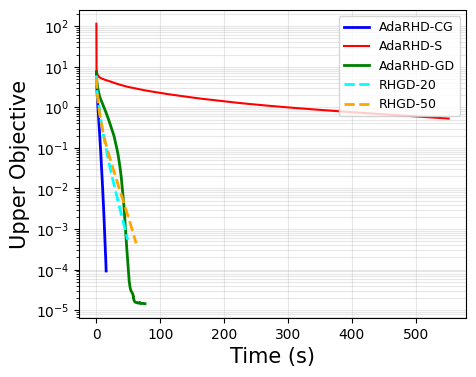

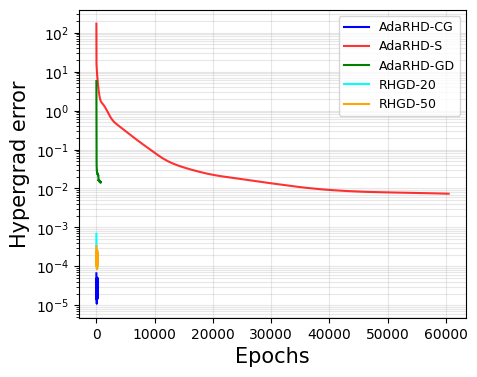

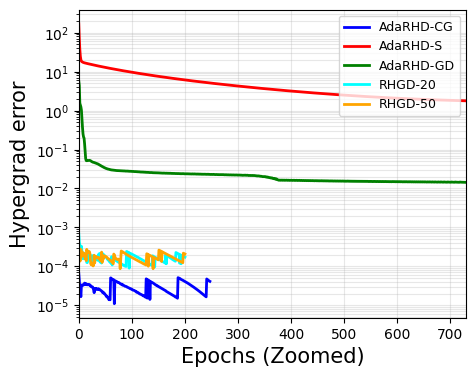

In [2]:
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 路径准备
# ==========================================
try:
    current_dir = os.getcwd()
    # 确保 fig 目录在结果目录同级
    fig_path = r"C:\Users\24300\Desktop\Ada_S\fig" 
except NameError:
    fig_path = "../fig"

if not os.path.exists(fig_path):
    os.makedirs(fig_path)

# 统一参数
lw = 2

# ==========================================
# 2. 绘制 Upper Objective vs Time
# ==========================================
plt.figure(figsize=(5, 4))

# 基础算法
plt.semilogy(AdaRHD_CG_runtime, AdaRHD_CG_loss, color='blue', label='AdaRHD-CG', linewidth=lw)
plt.semilogy(AdaRHD_S_runtime, AdaRHD_S_loss, color='red', label='AdaRHD-S', linewidth=1.5)
if 'AdaRHD_GD_loss' in locals():
    plt.semilogy(AdaRHD_GD_runtime, AdaRHD_GD_loss, color='green', label='AdaRHD-GD', linewidth=lw)

# 新增 RHGD 算法
plt.semilogy(RHGD20_runtime, RHGD20_loss, color='cyan', label='RHGD-20', linewidth=lw, linestyle='--')
plt.semilogy(RHGD50_runtime, RHGD50_loss, color='orange', label='RHGD-50', linewidth=lw, linestyle='--')

plt.xlabel('Time (s)', fontsize=15)
plt.ylabel('Upper Objective', fontsize=15)
plt.legend(fontsize=9, loc='upper right') # 算法较多，缩小字号并调整位置
plt.grid(alpha=0.3, which='both')

save_name_obj = os.path.join(fig_path, f'shallow_hyrep_{n}_{d}_{r}_upper_obj_time_all.pdf')
plt.savefig(save_name_obj, format='pdf', bbox_inches='tight')
plt.show()

# ==========================================
# 3. 绘制 Hypergrad error vs Epochs (全量版本)
# ==========================================
plt.figure(figsize=(5, 4))

plt.semilogy(range(len(AdaRHD_CG_hg_error)), AdaRHD_CG_hg_error, color='blue', label='AdaRHD-CG')
plt.semilogy(range(len(AdaRHD_S_hg_error)), AdaRHD_S_hg_error, color='red', label='AdaRHD-S', alpha=0.8)
if 'AdaRHD_GD_hg_error' in locals():
    plt.semilogy(range(len(AdaRHD_GD_hg_error)), AdaRHD_GD_hg_error, color='green', label='AdaRHD-GD')

# 新增 RHGD
plt.semilogy(range(len(RHGD20_hg_error)), RHGD20_hg_error, color='cyan', label='RHGD-20')
plt.semilogy(range(len(RHGD50_hg_error)), RHGD50_hg_error, color='orange', label='RHGD-50')

plt.xlabel('Epochs', fontsize=15)
plt.ylabel('Hypergrad error', fontsize=15)
plt.legend(fontsize=9, loc='upper right')
plt.grid(alpha=0.3, which='both')

save_full_err = os.path.join(fig_path, f'shallow_hyrep_{n}_{d}_{r}_hg_error_full_all.pdf')
plt.savefig(save_full_err, format='pdf', bbox_inches='tight')
plt.show()

# ==========================================
# 4. 绘制 Hypergrad error vs Epochs (放大版本: 0-730)
# ==========================================
plt.figure(figsize=(5, 4))

plt.semilogy(range(len(AdaRHD_CG_hg_error)), AdaRHD_CG_hg_error, color='blue', label='AdaRHD-CG', linewidth=lw)
plt.semilogy(range(len(AdaRHD_S_hg_error)), AdaRHD_S_hg_error, color='red', label='AdaRHD-S', linewidth=lw)
if 'AdaRHD_GD_hg_error' in locals():
    plt.semilogy(range(len(AdaRHD_GD_hg_error)), AdaRHD_GD_hg_error, color='green', label='AdaRHD-GD', linewidth=lw)

# 新增 RHGD 细节
plt.semilogy(range(len(RHGD20_hg_error)), RHGD20_hg_error, color='cyan', label='RHGD-20', linewidth=lw)
plt.semilogy(range(len(RHGD50_hg_error)), RHGD50_hg_error, color='orange', label='RHGD-50', linewidth=lw)

plt.xlim([0, 730]) 
plt.xlabel('Epochs (Zoomed)', fontsize=15)
plt.ylabel('Hypergrad error', fontsize=15)
plt.legend(fontsize=9, loc='upper right')
plt.grid(alpha=0.3, which='both')

save_zoom_err = os.path.join(fig_path, f'shallow_hyrep_{n}_{d}_{r}_hg_error_zoom730_all.pdf')
plt.savefig(save_zoom_err, format='pdf', bbox_inches='tight')
plt.show()